In [10]:
# Libraries and Dependencies
from fredapi import Fred
from dotenv import load_dotenv
from os import getenv
from pathlib import Path
import pandas as pd
import numpy as np

In [ ]:
load_dotenv()

# ============================================================================
# STEP 1: Setup (Get free key at https://fred.stlouisfed.org/)
# ============================================================================
fred = Fred(api_key=getenv('FRED_API_KEY'))

In [ ]:
# ============================================================================
# STEP 2: Get US Liquidity Index (3 lines of code!)
# ============================================================================

# Get the three key components
fed_balance = fred.get_series('WALCL')      # Fed Balance Sheet
tga = fred.get_series('WTREGEN')            # Treasury Account
rrp = fred.get_series('RRPONTSYD')          # Reverse Repo

# Calculate US Liquidity
df = pd.DataFrame({
    'Fed_Balance': fed_balance,
    'TGA': tga,
    'RRP': rrp
}).fillna(method='ffill')

df['US_Liquidity'] = df['Fed_Balance'] - df['TGA'] - df['RRP']

# Print results
print("=" * 60)
print("US LIQUIDITY INDEX")
print("=" * 60)
print(f"\nLatest Data ({df.index[-1].strftime('%Y-%m-%d')}):")
print(f"  US Liquidity: ${df['US_Liquidity'].iloc[-1]:,.0f} billion")
print(f"\nLast 10 weeks:")
print(df['US_Liquidity'].tail(10))

# Check trend
recent_change = df['US_Liquidity'].iloc[-1] - df['US_Liquidity'].iloc[-13]
print(f"\n13-Week Change: ${recent_change:,.0f}B")

if recent_change > 0:
    print("✅ LIQUIDITY EXPANDING - Bullish signal!")
else:
    print("⚠️  LIQUIDITY CONTRACTING - Bearish signal!")

# ============================================================================
# STEP 3: Get M2 Money Supply (even simpler!)
# ============================================================================

m2 = fred.get_series('M2SL')
print(f"\nM2 Money Supply: ${m2.iloc[-1]:,.0f}B")
print(f"Last 5 months:")
print(m2.tail(5))

# ============================================================================
# STEP 4: Export to CSV
# ============================================================================

# df.to_csv('/home/claude/us_liquidity_data.csv')
# print(f"\n✓ Data saved to 'us_liquidity_data.csv'")

# ============================================================================
# BONUS: Key Indicators in One Call
# ============================================================================

indicators = {
    'M2SL': 'M2 Money Supply',
    'WALCL': 'Fed Balance Sheet', 
    'DFF': 'Fed Funds Rate',
    'VIXCLS': 'VIX (Fear Index)',
    'T10Y2Y': 'Yield Curve (10Y-2Y)'
}

print("\n" + "=" * 60)
print("KEY MARKET INDICATORS")
print("=" * 60)

for code, name in indicators.items():
    series = fred.get_series(code)
    print(f"{name:25s}: {series.iloc[-1]:>10.2f}")

print("\n" + "=" * 60)
print("DONE! You now have liquidity data for trading.")
print("=" * 60)

C:\Users\Maverick\AppData\Local\Temp\ipykernel_4848\1027706153.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  }).fillna(method='ffill')


US LIQUIDITY INDEX

Latest Data (2025-12-26):
  US Liquidity: $5,723,748 billion

Last 10 weeks:
2025-12-15    5680354.399
2025-12-16    5680355.446
2025-12-17    5723757.639
2025-12-18    5723756.292
2025-12-19    5723764.953
2025-12-22    5723766.477
2025-12-23    5723762.107
2025-12-24    5723763.197
2025-12-25    5723763.197
2025-12-26    5723747.661
Name: US_Liquidity, dtype: float64

13-Week Change: $43,396B
✅ LIQUIDITY EXPANDING - Bullish signal!

M2 Money Supply: $22,322B
Last 5 months:
2025-07-01    22028.7
2025-08-01    22108.3
2025-09-01    22212.4
2025-10-01    22298.0
2025-11-01    22322.4
dtype: float64

KEY MARKET INDICATORS
M2 Money Supply          :   22322.40
Fed Balance Sheet        : 6556861.00
Fed Funds Rate           :       3.64
VIX (Fear Index)         :      13.47
Yield Curve (10Y-2Y)     :       0.68

DONE! You now have liquidity data for trading.


LIQUIDITY vs ASSET PRICES - CORRELATION ANALYSIS

📊 Step 1: Fetching Global Liquidity Data...


C:\Users\Maverick\AppData\Local\Temp\ipykernel_4848\2215949854.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  }).fillna(method='ffill')


✓ Liquidity data from 2018-01-01 to 2025-12-26

📈 Step 2: Fetching S&P 500 Data...
✓ S&P 500 data: 2085 data points

₿ Step 3: Crypto Data Note
----------------------------------------------------------------------

For Bitcoin data, you would typically use:
  - CoinGecko API (free)
  - Alpha Vantage API (includes crypto)
  - CoinAPI (institutional grade)

Example with Alpha Vantage:
  from alpha_vantage.cryptocurrencies import CryptoCurrencies
  cc = CryptoCurrencies(key='YOUR_KEY')
  btc_data, _ = cc.get_digital_currency_daily(symbol='BTC', market='USD')

For this demo, we'll analyze S&P 500 correlation.


🔄 Step 4: Aligning Data for Correlation Analysis...
✓ Merged dataset: 96 monthly data points

📊 Step 5: Correlation Analysis
----------------------------------------------------------------------

1. CURRENT CORRELATION:
   US Liquidity vs S&P 500: 0.481
   M2 vs S&P 500:           0.822

2. LAGGED CORRELATION (Liquidity leading S&P 500):
   Lag (months)    Correlation    
   -----

C:\Users\Maverick\AppData\Local\Temp\ipykernel_4848\2215949854.py:62: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  liquidity_monthly = liquidity_df['US_Liquidity'].resample('M').last()
C:\Users\Maverick\AppData\Local\Temp\ipykernel_4848\2215949854.py:63: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sp500_monthly = sp500.resample('M').last()
C:\Users\Maverick\AppData\Local\Temp\ipykernel_4848\2215949854.py:64: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  m2_monthly = liquidity_df['M2'].resample('M').last()


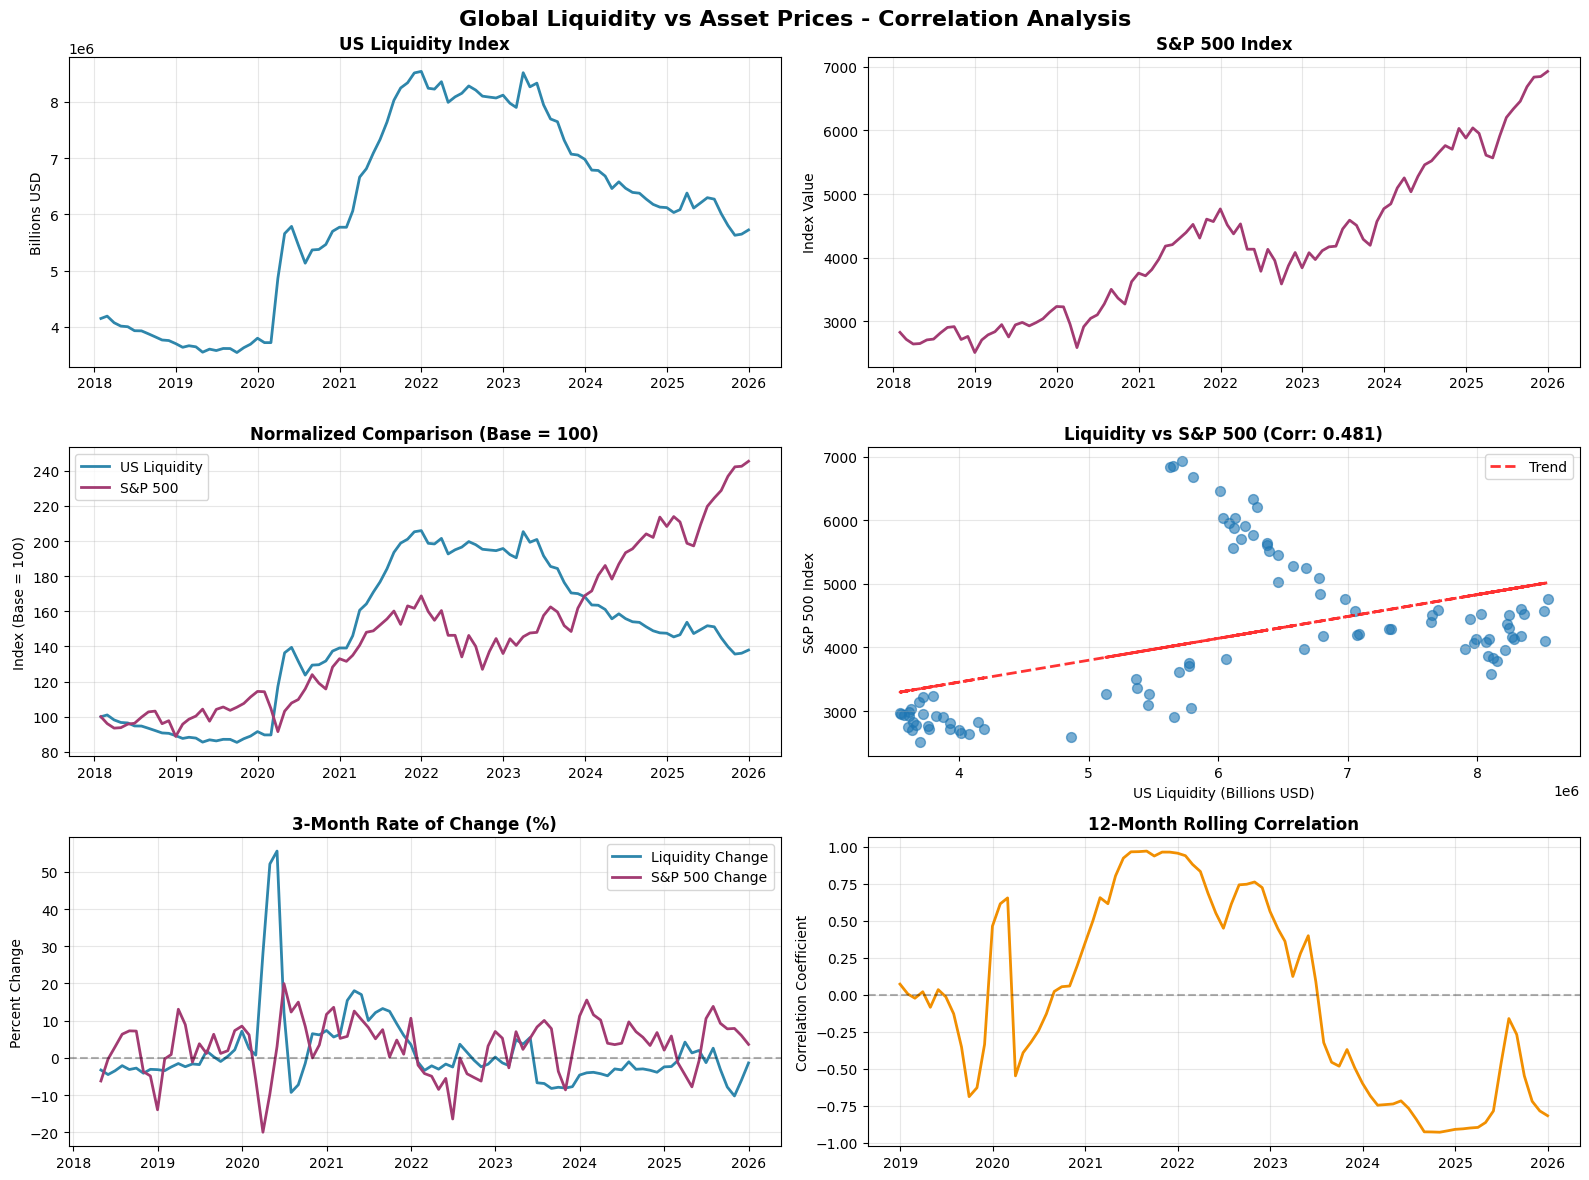

In [13]:


print("=" * 70)
print("LIQUIDITY vs ASSET PRICES - CORRELATION ANALYSIS")
print("=" * 70)

# ============================================================================
# STEP 1: Get Global Liquidity Data
# ============================================================================
print("\n📊 Step 1: Fetching Global Liquidity Data...")

# Get US liquidity components
fed_assets = fred.get_series('WALCL', observation_start='2018-01-01')
tga = fred.get_series('WTREGEN', observation_start='2018-01-01')
rrp = fred.get_series('RRPONTSYD', observation_start='2018-01-01')
m2 = fred.get_series('M2SL', observation_start='2018-01-01')

# Create liquidity dataframe
liquidity_df = pd.DataFrame({
    'FED': fed_assets,
    'TGA': tga,
    'RRP': rrp,
    'M2': m2
}).fillna(method='ffill')

# Calculate US Liquidity Index
liquidity_df['US_Liquidity'] = liquidity_df['FED'] - liquidity_df['TGA'] - liquidity_df['RRP']

print(f"✓ Liquidity data from {liquidity_df.index[0].strftime('%Y-%m-%d')} to {liquidity_df.index[-1].strftime('%Y-%m-%d')}")

# ============================================================================
# STEP 2: Get S&P 500 Data from FRED
# ============================================================================
print("\n📈 Step 2: Fetching S&P 500 Data...")

sp500 = fred.get_series('SP500', observation_start='2018-01-01')
print(f"✓ S&P 500 data: {len(sp500)} data points")

# ============================================================================
# STEP 3: Note on Crypto Data
# ============================================================================
print("\n₿ Step 3: Crypto Data Note")
print("-" * 70)
print("""
For Bitcoin data, you would typically use:
  - CoinGecko API (free)
  - Alpha Vantage API (includes crypto)
  - CoinAPI (institutional grade)

Example with Alpha Vantage:
  from alpha_vantage.cryptocurrencies import CryptoCurrencies
  cc = CryptoCurrencies(key='YOUR_KEY')
  btc_data, _ = cc.get_digital_currency_daily(symbol='BTC', market='USD')

For this demo, we'll analyze S&P 500 correlation.
""")

# ============================================================================
# STEP 4: Align and Merge Data
# ============================================================================
print("\n🔄 Step 4: Aligning Data for Correlation Analysis...")

# Resample to monthly for better alignment
liquidity_monthly = liquidity_df['US_Liquidity'].resample('M').last()
sp500_monthly = sp500.resample('M').last()
m2_monthly = liquidity_df['M2'].resample('M').last()

# Merge datasets
analysis_df = pd.DataFrame({
    'Liquidity': liquidity_monthly,
    'M2': m2_monthly,
    'SP500': sp500_monthly
}).dropna()

print(f"✓ Merged dataset: {len(analysis_df)} monthly data points")

# ============================================================================
# STEP 5: Calculate Correlations
# ============================================================================
print("\n📊 Step 5: Correlation Analysis")
print("-" * 70)

# Current correlation (no lag)
corr_liquidity = analysis_df['Liquidity'].corr(analysis_df['SP500'])
corr_m2 = analysis_df['M2'].corr(analysis_df['SP500'])

print(f"\n1. CURRENT CORRELATION:")
print(f"   US Liquidity vs S&P 500: {corr_liquidity:.3f}")
print(f"   M2 vs S&P 500:           {corr_m2:.3f}")

# Lagged correlation (liquidity leads markets by X weeks)
print(f"\n2. LAGGED CORRELATION (Liquidity leading S&P 500):")
print(f"   {'Lag (months)':<15} {'Correlation':<15}")
print(f"   {'-'*30}")

best_lag = 0
best_corr = 0

for lag in range(0, 13):  # Test 0-12 month lags
    # Shift SP500 backwards (liquidity leads)
    sp500_shifted = analysis_df['SP500'].shift(-lag)
    corr = analysis_df['Liquidity'].corr(sp500_shifted)
    print(f"   {lag:<15} {corr:<15.3f}")
    
    if abs(corr) > abs(best_corr):
        best_corr = corr
        best_lag = lag

print(f"\n   Best correlation: {best_corr:.3f} at {best_lag}-month lag")

# ============================================================================
# STEP 6: Calculate Changes (Rate of Change)
# ============================================================================
print("\n📈 Step 6: Analyzing Rate of Change")
print("-" * 70)

# Calculate percentage changes
analysis_df['Liquidity_Change'] = analysis_df['Liquidity'].pct_change(periods=3) * 100  # 3-month
analysis_df['SP500_Change'] = analysis_df['SP500'].pct_change(periods=3) * 100

# Correlation of changes
corr_changes = analysis_df['Liquidity_Change'].corr(analysis_df['SP500_Change'])
print(f"\n3-Month Change Correlation: {corr_changes:.3f}")
print(f"(Higher correlation often found in rate-of-change)")

# ============================================================================
# STEP 7: Visualizations
# ============================================================================
print("\n📊 Step 7: Creating Visualizations...")

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Global Liquidity vs Asset Prices - Correlation Analysis', 
             fontsize=16, fontweight='bold')

# Plot 1: US Liquidity over time
ax1 = axes[0, 0]
ax1.plot(analysis_df.index, analysis_df['Liquidity'], linewidth=2, color='#2E86AB')
ax1.set_title('US Liquidity Index', fontweight='bold')
ax1.set_ylabel('Billions USD')
ax1.grid(True, alpha=0.3)

# Plot 2: S&P 500 over time
ax2 = axes[0, 1]
ax2.plot(analysis_df.index, analysis_df['SP500'], linewidth=2, color='#A23B72')
ax2.set_title('S&P 500 Index', fontweight='bold')
ax2.set_ylabel('Index Value')
ax2.grid(True, alpha=0.3)

# Plot 3: Normalized overlay
ax3 = axes[1, 0]
# Normalize both to start at 100
liquidity_norm = (analysis_df['Liquidity'] / analysis_df['Liquidity'].iloc[0]) * 100
sp500_norm = (analysis_df['SP500'] / analysis_df['SP500'].iloc[0]) * 100
ax3.plot(analysis_df.index, liquidity_norm, label='US Liquidity', linewidth=2, color='#2E86AB')
ax3.plot(analysis_df.index, sp500_norm, label='S&P 500', linewidth=2, color='#A23B72')
ax3.set_title('Normalized Comparison (Base = 100)', fontweight='bold')
ax3.set_ylabel('Index (Base = 100)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Scatter plot
ax4 = axes[1, 1]
ax4.scatter(analysis_df['Liquidity'], analysis_df['SP500'], alpha=0.6, s=50)
ax4.set_title(f'Liquidity vs S&P 500 (Corr: {corr_liquidity:.3f})', fontweight='bold')
ax4.set_xlabel('US Liquidity (Billions USD)')
ax4.set_ylabel('S&P 500 Index')
ax4.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(analysis_df['Liquidity'].dropna(), analysis_df['SP500'].dropna(), 1)
p = np.poly1d(z)
ax4.plot(analysis_df['Liquidity'], p(analysis_df['Liquidity']), 
         "r--", alpha=0.8, linewidth=2, label='Trend')
ax4.legend()

# Plot 5: Rate of Change comparison
ax5 = axes[2, 0]
ax5.plot(analysis_df.index, analysis_df['Liquidity_Change'], 
         label='Liquidity Change', linewidth=2, color='#2E86AB')
ax5.plot(analysis_df.index, analysis_df['SP500_Change'], 
         label='S&P 500 Change', linewidth=2, color='#A23B72')
ax5.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax5.set_title('3-Month Rate of Change (%)', fontweight='bold')
ax5.set_ylabel('Percent Change')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Rolling Correlation
ax6 = axes[2, 1]
rolling_corr = analysis_df['Liquidity'].rolling(window=12).corr(analysis_df['SP500'])
ax6.plot(analysis_df.index, rolling_corr, linewidth=2, color='#F18F01')
ax6.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax6.set_title('12-Month Rolling Correlation', fontweight='bold')
ax6.set_ylabel('Correlation Coefficient')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('/home/claude/liquidity_correlation_analysis.png', dpi=150, bbox_inches='tight')
# # print("✓ Visualization saved as 'liquidity_correlation_analysis.png'")

# ============================================================================
# STEP 8: Trading Signals
# ============================================================================
print("\n🎯 Step 8: Current Trading Signals")
print("-" * 70)

# Get recent values
recent_liquidity = analysis_df['Liquidity'].tail(3)
recent_sp500 = analysis_df['SP500'].tail(3)

# Calculate recent trends
liquidity_trend = ((recent_liquidity.iloc[-1] / recent_liquidity.iloc[0]) - 1) * 100
sp500_trend = ((recent_sp500.iloc[-1] / recent_sp500.iloc[0]) - 1) * 100

print(f"\nRecent Trends (Last 3 months):")
print(f"  Liquidity: {liquidity_trend:+.2f}%")
print(f"  S&P 500:   {sp500_trend:+.2f}%")

# Trading signal
if liquidity_trend > 2:
    signal = "🟢 BULLISH"
    explanation = "Liquidity expanding rapidly - historically bullish for risk assets"
elif liquidity_trend > 0:
    signal = "🟡 NEUTRAL-BULLISH"
    explanation = "Liquidity expanding moderately - mildly bullish"
elif liquidity_trend > -2:
    signal = "🟡 NEUTRAL-BEARISH"
    explanation = "Liquidity contracting moderately - mildly bearish"
else:
    signal = "🔴 BEARISH"
    explanation = "Liquidity contracting rapidly - historically bearish for risk assets"

print(f"\nCurrent Signal: {signal}")
print(f"Reasoning: {explanation}")

# ============================================================================
# STEP 9: Summary Statistics
# ============================================================================
print("\n📊 Step 9: Summary Statistics")
print("-" * 70)

print(f"""
CORRELATION SUMMARY:
  Current Liquidity-SP500:     {corr_liquidity:.3f}
  Current M2-SP500:            {corr_m2:.3f}
  Rate of Change Correlation:  {corr_changes:.3f}
  Best Lagged Correlation:     {best_corr:.3f} ({best_lag} months)
  
INTERPRETATION:
  - Correlation > 0.7:  Strong positive relationship
  - Correlation 0.4-0.7: Moderate positive relationship
  - Correlation < 0.4:   Weak relationship
  
TRADING INSIGHTS:
  - Liquidity tends to lead asset prices by {best_lag} months
  - When liquidity expands, risk assets typically rally
  - When liquidity contracts, risk assets typically decline
  - Best used as a macro timing tool, not day-trading signal
  
NEXT STEPS:
  1. Add Bitcoin data for crypto correlation
  2. Set up automated alerts for liquidity changes
  3. Combine with other indicators (VIX, yield curve)
  4. Track Fed policy announcements
""")

print("\n" + "=" * 70)
print("Analysis Complete! 🎉")
print("=" * 70)
print("\nFiles created:")
print("  - liquidity_correlation_analysis.png")
print("\nTo run with Bitcoin:")
print("  1. Get Alpha Vantage API key (free)")
print("  2. Use CoinGecko API for crypto prices")
print("  3. Replace S&P 500 analysis with BTC data")


📊 EXAMPLE 1: Getting M2 Money Supply (US)
----------------------------------------------------------------------
Latest M2 Money Supply: $22,322 billion
Data from: 1959-01-01 to 2025-11-01
Total data points: 803

Last 5 values:
2025-07-01    22028.7
2025-08-01    22108.3
2025-09-01    22212.4
2025-10-01    22298.0
2025-11-01    22322.4
dtype: float64


📈 EXAMPLE 2: Fetching Multiple Liquidity Indicators
----------------------------------------------------------------------
✓ M2 Money Supply: Latest = $22,322B (as of 2025-11-01)
✓ Federal Reserve Total Assets: Latest = $6,556,861B (as of 2025-12-17)
✓ Treasury General Account: Latest = $833,093B (as of 2025-12-17)
✓ Overnight Reverse Repo: Latest = $20B (as of 2025-12-26)
✓ M2 Money Supply (Weekly): Latest = $22,430B (as of 2025-12-01)


💧 EXAMPLE 3: Calculating US Liquidity Index
----------------------------------------------------------------------


C:\Users\Maverick\AppData\Local\Temp\ipykernel_4848\3684403829.py:83: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
C:\Users\Maverick\AppData\Local\Temp\ipykernel_4848\3684403829.py:90: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent_df = df.last('180D')



US Liquidity Index Formula:
US Liquidity = Fed Balance Sheet - TGA - Reverse Repo

Latest Values (as of 2025-12-26):
  Fed Balance Sheet: $6,556,861 billion
  - TGA:             $833,093 billion
  - Reverse Repo:    $20 billion
  = US Liquidity:    $5,723,748 billion

3-Month Change: $-375,086B (-6.15%)
📉 Liquidity is CONTRACTING - Bearish for risk assets!


🔍 EXAMPLE 4: Searching for Data Series
----------------------------------------------------------------------
Found 1000 series related to 'unemployment rate'

Top 5 results:
                                                     title  frequency    units
series id                                                                     
UNRATE                                   Unemployment Rate    Monthly  Percent
UNRATENSA                                Unemployment Rate    Monthly  Percent
LNS14000006  Unemployment Rate - Black or African American    Monthly  Percent
LNU04000006  Unemployment Rate - Black or African American    Monthl

C:\Users\Maverick\AppData\Local\Temp\ipykernel_4848\3684403829.py:194: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent_liq = df['US_Liquidity'].last('730D')  # Last 2 years
C:\Users\Maverick\AppData\Local\Temp\ipykernel_4848\3684403829.py:204: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  components = df[['FED', 'TGA', 'RRP']].last('730D')


Error creating visualizations: [Errno 2] No such file or directory: '/home/claude/fred_liquidity_analysis.png'


📋 EXAMPLE 8: Getting Detailed Series Information
----------------------------------------------------------------------

M2 Money Supply - Series Information:
  Title: M2
  Frequency: Monthly
  Units: Billions of Dollars
  Seasonal Adjustment: Seasonally Adjusted
  Last Updated: 2025-12-23 12:01:38-06
  Observation Start: 1959-01-01
  Observation End: 2025-11-01


🌍 EXAMPLE 9: Additional Economic Data for Global Context
----------------------------------------------------------------------

Key Economic Indicators:
  US Monetary Base: 5,301.90 (-5.59% YoY)
  30-Year Mortgage Rate: 6.18 (-2.52% YoY)
  Unemployment Rate: 4.60 (+9.52% YoY)
  Consumer Price Index: 325.03 (+2.71% YoY)
  Gross Domestic Product: 31,095.09 (+18.07% YoY)


📊 SUMMARY - Trading with FRED Data

Key Takeaways:

1. **Global Liquidity Components:**
   - Federal Reserve Balance Sheet (WALCL)
   - Treasury G

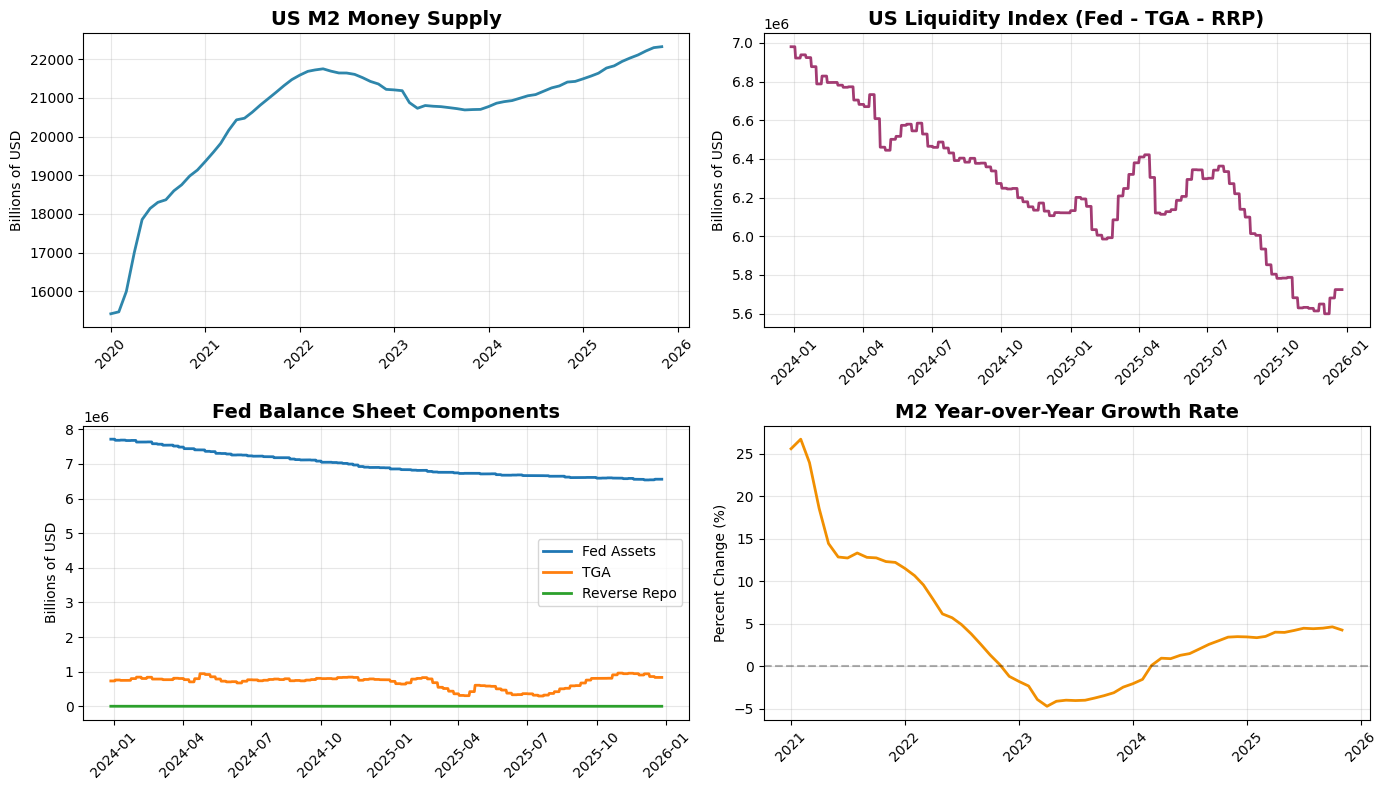

In [15]:
"""
FRED API Tutorial - Global Liquidity Tracking
==============================================

This script demonstrates how to use the FRED API to track global liquidity
and correlate it with stocks and crypto markets.

Author: Tutorial Example
Date: December 2025
"""

# ============================================================================
# INSTALLATION
# ============================================================================
# Run this first:
# pip install fredapi pandas matplotlib seaborn --break-system-packages

import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
from datetime import datetime, timedelta

# ============================================================================
# EXAMPLE 1: Basic Data Retrieval
# ============================================================================
print("\n📊 EXAMPLE 1: Getting M2 Money Supply (US)")
print("-" * 70)

# Get M2 money supply data (monthly)
m2 = fred.get_series('M2SL')

print(f"Latest M2 Money Supply: ${m2.iloc[-1]:,.0f} billion")
print(f"Data from: {m2.index[0].strftime('%Y-%m-%d')} to {m2.index[-1].strftime('%Y-%m-%d')}")
print(f"Total data points: {len(m2)}")
print("\nLast 5 values:")
print(m2.tail())

# ============================================================================
# EXAMPLE 2: Multiple Economic Indicators
# ============================================================================
print("\n\n📈 EXAMPLE 2: Fetching Multiple Liquidity Indicators")
print("-" * 70)

# Dictionary of key liquidity indicators
liquidity_indicators = {
    'M2SL': 'M2 Money Supply',
    'WALCL': 'Federal Reserve Total Assets',
    'WTREGEN': 'Treasury General Account',
    'RRPONTSYD': 'Overnight Reverse Repo',
    'WM2NS': 'M2 Money Supply (Weekly)'
}

# Fetch all indicators
data = {}
for code, name in liquidity_indicators.items():
    try:
        series = fred.get_series(code)
        data[name] = series
        print(f"✓ {name}: Latest = ${series.iloc[-1]:,.0f}B (as of {series.index[-1].strftime('%Y-%m-%d')})")
    except Exception as e:
        print(f"✗ {name}: Error - {e}")

# ============================================================================
# EXAMPLE 3: Building a US Liquidity Index
# ============================================================================
print("\n\n💧 EXAMPLE 3: Calculating US Liquidity Index")
print("-" * 70)

# Get components (use weekly data for more frequent updates)
try:
    fed_assets = fred.get_series('WALCL')  # Fed Balance Sheet
    tga = fred.get_series('WTREGEN')       # Treasury General Account
    rrp = fred.get_series('RRPONTSYD')     # Reverse Repo
    
    # Align all series to the same dates
    df = pd.DataFrame({
        'FED': fed_assets,
        'TGA': tga,
        'RRP': rrp
    })
    
    # Forward fill missing values
    df = df.fillna(method='ffill')
    
    # Calculate US Liquidity Index
    # Formula: Fed Assets - TGA - RRP
    df['US_Liquidity'] = df['FED'] - df['TGA'] - df['RRP']
    
    # Get recent data (last 6 months)
    recent_df = df.last('180D')
    
    print("\nUS Liquidity Index Formula:")
    print("US Liquidity = Fed Balance Sheet - TGA - Reverse Repo\n")
    
    print(f"Latest Values (as of {df.index[-1].strftime('%Y-%m-%d')}):")
    print(f"  Fed Balance Sheet: ${df['FED'].iloc[-1]:,.0f} billion")
    print(f"  - TGA:             ${df['TGA'].iloc[-1]:,.0f} billion")
    print(f"  - Reverse Repo:    ${df['RRP'].iloc[-1]:,.0f} billion")
    print(f"  = US Liquidity:    ${df['US_Liquidity'].iloc[-1]:,.0f} billion")
    
    # Calculate change over last 3 months
    three_months_ago = df['US_Liquidity'].iloc[-90] if len(df) > 90 else df['US_Liquidity'].iloc[0]
    change = df['US_Liquidity'].iloc[-1] - three_months_ago
    pct_change = (change / three_months_ago) * 100
    
    print(f"\n3-Month Change: ${change:,.0f}B ({pct_change:+.2f}%)")
    
    if pct_change > 0:
        print("📈 Liquidity is EXPANDING - Bullish for risk assets!")
    else:
        print("📉 Liquidity is CONTRACTING - Bearish for risk assets!")
    
except Exception as e:
    print(f"Error calculating liquidity index: {e}")

# ============================================================================
# EXAMPLE 4: Search for Data Series
# ============================================================================
print("\n\n🔍 EXAMPLE 4: Searching for Data Series")
print("-" * 70)

# Search for data related to specific topics
search_results = fred.search('unemployment rate')
print(f"Found {len(search_results)} series related to 'unemployment rate'")
print("\nTop 5 results:")
print(search_results[['title', 'frequency', 'units']].head())

# ============================================================================
# EXAMPLE 5: Historical Data with Date Ranges
# ============================================================================
print("\n\n📅 EXAMPLE 5: Getting Data for Specific Date Ranges")
print("-" * 70)

# Get data from specific date range
start_date = '2020-01-01'
end_date = '2025-12-31'

m2_recent = fred.get_series('M2SL', observation_start=start_date, observation_end=end_date)

print(f"M2 Money Supply from {start_date} to {end_date}")
print(f"Starting value: ${m2_recent.iloc[0]:,.0f}B")
print(f"Ending value:   ${m2_recent.iloc[-1]:,.0f}B")
print(f"Total change:   ${m2_recent.iloc[-1] - m2_recent.iloc[0]:,.0f}B")
print(f"Percent change: {((m2_recent.iloc[-1] / m2_recent.iloc[0]) - 1) * 100:.2f}%")

# ============================================================================
# EXAMPLE 6: Economic Indicators for Market Correlation
# ============================================================================
print("\n\n🎯 EXAMPLE 6: Key Economic Indicators for Trading")
print("-" * 70)

key_indicators = {
    'DFF': 'Federal Funds Rate',
    'T10Y2Y': '10Y-2Y Treasury Spread',
    'DEXUSEU': 'USD/EUR Exchange Rate',
    'VIXCLS': 'VIX (Volatility Index)',
    'DCOILWTICO': 'WTI Crude Oil Price'
}

print("\nCurrent values:")
for code, name in key_indicators.items():
    try:
        series = fred.get_series(code)
        latest_value = series.iloc[-1]
        latest_date = series.index[-1].strftime('%Y-%m-%d')
        print(f"  {name}: {latest_value:.2f} (as of {latest_date})")
    except Exception as e:
        print(f"  {name}: Error fetching data")

# ============================================================================
# EXAMPLE 7: Creating Visualizations
# ============================================================================
print("\n\n📊 EXAMPLE 7: Creating Visualizations")
print("-" * 70)

try:
    # Get recent M2 data for plotting
    m2_plot = fred.get_series('M2SL', observation_start='2020-01-01')
    
    # Create figure
    plt.figure(figsize=(14, 8))
    
    # Plot 1: M2 Money Supply
    plt.subplot(2, 2, 1)
    plt.plot(m2_plot.index, m2_plot.values, linewidth=2, color='#2E86AB')
    plt.title('US M2 Money Supply', fontsize=14, fontweight='bold')
    plt.ylabel('Billions of USD')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Plot 2: US Liquidity Index (if we have the data)
    if 'df' in locals() and 'US_Liquidity' in df.columns:
        plt.subplot(2, 2, 2)
        recent_liq = df['US_Liquidity'].last('730D')  # Last 2 years
        plt.plot(recent_liq.index, recent_liq.values, linewidth=2, color='#A23B72')
        plt.title('US Liquidity Index (Fed - TGA - RRP)', fontsize=14, fontweight='bold')
        plt.ylabel('Billions of USD')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
    
    # Plot 3: Fed Balance Sheet Components
    plt.subplot(2, 2, 3)
    if 'df' in locals():
        components = df[['FED', 'TGA', 'RRP']].last('730D')
        plt.plot(components.index, components['FED'], label='Fed Assets', linewidth=2)
        plt.plot(components.index, components['TGA'], label='TGA', linewidth=2)
        plt.plot(components.index, components['RRP'], label='Reverse Repo', linewidth=2)
        plt.title('Fed Balance Sheet Components', fontsize=14, fontweight='bold')
        plt.ylabel('Billions of USD')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
    
    # Plot 4: M2 Growth Rate
    plt.subplot(2, 2, 4)
    m2_growth = m2_plot.pct_change(periods=12) * 100  # Year-over-year % change
    plt.plot(m2_growth.index, m2_growth.values, linewidth=2, color='#F18F01')
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    plt.title('M2 Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
    plt.ylabel('Percent Change (%)')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig('/home/claude/fred_liquidity_analysis.png', dpi=150, bbox_inches='tight')
    print("✓ Visualization saved as 'fred_liquidity_analysis.png'")
    
except Exception as e:
    print(f"Error creating visualizations: {e}")

# ============================================================================
# EXAMPLE 8: Getting Series Information
# ============================================================================
print("\n\n📋 EXAMPLE 8: Getting Detailed Series Information")
print("-" * 70)

# Get detailed info about a series
m2_info = fred.get_series_info('M2SL')
print("\nM2 Money Supply - Series Information:")
print(f"  Title: {m2_info['title']}")
print(f"  Frequency: {m2_info['frequency']}")
print(f"  Units: {m2_info['units']}")
print(f"  Seasonal Adjustment: {m2_info['seasonal_adjustment']}")
print(f"  Last Updated: {m2_info['last_updated']}")
print(f"  Observation Start: {m2_info['observation_start']}")
print(f"  Observation End: {m2_info['observation_end']}")

# ============================================================================
# EXAMPLE 9: Global Liquidity Proxy (Major Central Banks)
# ============================================================================
print("\n\n🌍 EXAMPLE 9: Additional Economic Data for Global Context")
print("-" * 70)

# Additional economic indicators
additional_indicators = {
    'BOGMBASE': 'US Monetary Base',
    'MORTGAGE30US': '30-Year Mortgage Rate',
    'UNRATE': 'Unemployment Rate',
    'CPIAUCSL': 'Consumer Price Index',
    'GDP': 'Gross Domestic Product'
}

print("\nKey Economic Indicators:")
for code, name in additional_indicators.items():
    try:
        series = fred.get_series(code)
        latest_value = series.iloc[-1]
        latest_date = series.index[-1].strftime('%Y-%m-%d')
        
        # Calculate YoY change if possible
        year_ago_idx = len(series) - 13 if len(series) > 13 else 0
        if year_ago_idx > 0:
            year_ago_value = series.iloc[year_ago_idx]
            yoy_change = ((latest_value / year_ago_value) - 1) * 100
            print(f"  {name}: {latest_value:,.2f} ({yoy_change:+.2f}% YoY)")
        else:
            print(f"  {name}: {latest_value:,.2f}")
    except Exception as e:
        print(f"  {name}: Unable to fetch")

# ============================================================================
# SUMMARY & TRADING INSIGHTS
# ============================================================================
print("\n\n" + "="*70)
print("📊 SUMMARY - Trading with FRED Data")
print("="*70)

print("""
Key Takeaways:

1. **Global Liquidity Components:**
   - Federal Reserve Balance Sheet (WALCL)
   - Treasury General Account (WTREGEN) 
   - Reverse Repo Operations (RRPONTSYD)
   - M2 Money Supply (M2SL, WM2NS)

2. **Liquidity Formula:**
   US Liquidity = Fed Assets - TGA - Reverse Repo
   
3. **Market Correlation:**
   - Rising liquidity → Bullish for stocks & crypto
   - Falling liquidity → Bearish for risk assets
   - Typical lag: 8-12 weeks
   
4. **Update Frequency:**
   - M2: Weekly (WM2NS) or Monthly (M2SL)
   - Fed Balance: Weekly (WALCL)
   - TGA: Weekly (WTREGEN)
   - RRP: Daily (RRPONTSYD)

5. **API Rate Limits:**
   - Free tier: 50,000 calls/day
   - No authentication required after API key setup
   
6. **Best Practices:**
   - Cache data locally to reduce API calls
   - Use weekly data for semi-real-time tracking
   - Combine with crypto/stock APIs for correlation
   - Monitor trends, not absolute values

7. **Next Steps:**
   - Get your free API key: https://fred.stlouisfed.org/
   - Combine with Alpha Vantage for stock prices
   - Add CoinGecko for crypto correlation
   - Build automated alerts for liquidity changes
""")

print("\n" + "="*70)
print("Tutorial Complete! 🎉")
print("="*70)
print("\nReplace 'YOUR_API_KEY_HERE' with your actual API key to run this script.")
print("Get your free key at: https://fred.stlouisfed.org/")

In [16]:
"""
Daily & Intraday Liquidity Tracker
==================================

This script tracks liquidity using the best FREE data sources:
- DAILY: Reverse Repo, Fed Funds, VIX (FRED)
- WEEKLY: Fed Balance, M2, TGA (FRED) 
- MARKET PROXIES: S&P 500 (FRED), Bitcoin (CoinGecko)

ONLY ONE API KEY NEEDED: FRED (free from https://fred.stlouisfed.org/)

Run this script daily to track liquidity changes!
"""

import pandas as pd
from fredapi import Fred
import requests
from datetime import datetime, timedelta
import time


# ============================================================================
# FUNCTION: Get Daily Liquidity Data from FRED
# ============================================================================

def get_daily_liquidity():
    """
    Get BEST available daily liquidity data.
    Reverse Repo is updated DAILY - this is your daily liquidity signal!
    """
    print("📊 Fetching Daily Liquidity Data...")
    
    try:
        # Daily data (most important!)
        rrp = fred.get_series('RRPONTSYD')              # Reverse Repo - DAILY
        fed_funds = fred.get_series('DFF')              # Fed Funds Rate - DAILY
        vix = fred.get_series('VIXCLS')                # VIX - DAILY
        
        # Get last few days
        recent_rrp = rrp.tail(5)
        
        # Calculate daily change
        rrp_today = rrp.iloc[-1]
        rrp_yesterday = rrp.iloc[-2] if len(rrp) > 1 else rrp_today
        rrp_change = rrp_today - rrp_yesterday
        rrp_pct_change = (rrp_change / rrp_yesterday * 100) if rrp_yesterday != 0 else 0
        
        print(f"\n✅ DAILY LIQUIDITY DATA (as of {rrp.index[-1].strftime('%Y-%m-%d')})")
        print(f"   Reverse Repo:  ${rrp_today:,.0f}B")
        print(f"   Daily Change:  ${rrp_change:,.0f}B ({rrp_pct_change:+.2f}%)")
        print(f"   Fed Funds:     {fed_funds.iloc[-1]:.2f}%")
        print(f"   VIX:           {vix.iloc[-1]:.2f}")
        
        # Interpret RRP change
        if rrp_pct_change < -1:
            signal = "🟢 BULLISH - RRP draining, liquidity flowing to markets!"
        elif rrp_pct_change > 1:
            signal = "🔴 BEARISH - RRP rising, money parking at Fed!"
        else:
            signal = "🟡 NEUTRAL - No significant RRP change"
        
        print(f"\n   Signal: {signal}")
        
        return {
            'rrp': rrp_today,
            'rrp_change': rrp_change,
            'rrp_pct_change': rrp_pct_change,
            'fed_funds': fed_funds.iloc[-1],
            'vix': vix.iloc[-1],
            'date': rrp.index[-1]
        }
        
    except Exception as e:
        print(f"❌ Error fetching daily data: {e}")
        return None

# ============================================================================
# FUNCTION: Get Weekly Comprehensive Liquidity
# ============================================================================

def get_weekly_liquidity():
    """
    Get weekly Fed balance sheet data.
    Updated every Wednesday - use this for comprehensive liquidity tracking.
    """
    print("\n📊 Fetching Weekly Liquidity Data...")
    
    try:
        # Weekly data
        fed_balance = fred.get_series('WALCL')          # Fed Balance - WEEKLY (Wed)
        tga = fred.get_series('WTREGEN')               # TGA - WEEKLY (Wed)
        m2 = fred.get_series('WM2NS')                  # M2 - WEEKLY (Mon)
        
        # Get latest reverse repo for calculation
        rrp = fred.get_series('RRPONTSYD')
        rrp_weekly = rrp.resample('W').last()
        
        # Align all to same dates
        df = pd.DataFrame({
            'FED': fed_balance,
            'TGA': tga,
            'RRP': rrp_weekly,
            'M2': m2
        }).fillna(method='ffill')
        
        # Calculate US Liquidity Index
        df['US_Liquidity'] = df['FED'] - df['TGA'] - df['RRP']
        
        # Get latest values
        latest = df.iloc[-1]
        prev_week = df.iloc[-2] if len(df) > 1 else df.iloc[-1]
        
        liquidity_change = latest['US_Liquidity'] - prev_week['US_Liquidity']
        liquidity_pct = (liquidity_change / prev_week['US_Liquidity'] * 100) if prev_week['US_Liquidity'] != 0 else 0
        
        print(f"\n✅ WEEKLY LIQUIDITY INDEX (as of {df.index[-1].strftime('%Y-%m-%d')})")
        print(f"   Fed Balance:    ${latest['FED']:,.0f}B")
        print(f"   - TGA:          ${latest['TGA']:,.0f}B")
        print(f"   - Reverse Repo: ${latest['RRP']:,.0f}B")
        print(f"   ───────────────────────────────")
        print(f"   = US Liquidity: ${latest['US_Liquidity']:,.0f}B")
        print(f"   Weekly Change:  ${liquidity_change:,.0f}B ({liquidity_pct:+.2f}%)")
        print(f"\n   M2 Money:       ${latest['M2']:,.0f}B")
        
        # Interpret weekly change
        if liquidity_pct > 0.5:
            signal = "🟢 EXPANDING - Bullish macro trend!"
        elif liquidity_pct < -0.5:
            signal = "🔴 CONTRACTING - Bearish macro trend!"
        else:
            signal = "🟡 STABLE - No major trend change"
        
        print(f"\n   Trend: {signal}")
        
        return df.tail(13)  # Return last 13 weeks (quarter)
        
    except Exception as e:
        print(f"❌ Error fetching weekly data: {e}")
        return None

# ============================================================================
# FUNCTION: Get Intraday Market Proxies (Optional)
# ============================================================================

def get_intraday_proxies():
    """
    Get market proxies as liquidity indicators.
    - Bitcoin: Real-time from CoinGecko (free, no API key)
    - S&P 500: Daily from FRED (same API key)
    
    These react to liquidity changes quickly.
    """
    print("\n📊 Fetching Intraday Market Proxies...")
    
    proxies = {}
    
    # Bitcoin (CoinGecko - Free, real-time)
    try:
        url = "https://api.coingecko.com/api/v3/simple/price"
        params = {
            'ids': 'bitcoin',
            'vs_currencies': 'usd',
            'include_24hr_change': 'true'
        }
        response = requests.get(url, params=params)
        btc_data = response.json()
        
        proxies['btc_price'] = btc_data['bitcoin']['usd']
        proxies['btc_change_24h'] = btc_data['bitcoin']['usd_24h_change']
        
        print(f"   Bitcoin: ${proxies['btc_price']:,.2f} ({proxies['btc_change_24h']:+.2f}%)")
        
    except Exception as e:
        print(f"   ⚠️  Bitcoin data unavailable: {e}")
    
    # S&P 500 from FRED (Daily data - free, no extra API key needed!)
    try:
        sp500 = fred.get_series('SP500')  # S&P 500 daily close
        sp500_today = sp500.iloc[-1]
        sp500_yesterday = sp500.iloc[-2] if len(sp500) > 1 else sp500_today
        sp500_change = sp500_today - sp500_yesterday
        sp500_pct = (sp500_change / sp500_yesterday * 100) if sp500_yesterday != 0 else 0
        
        proxies['spy_price'] = sp500_today
        proxies['spy_change'] = sp500_change
        proxies['spy_change_pct'] = sp500_pct
        
        print(f"   S&P 500: {proxies['spy_price']:.2f} ({proxies['spy_change_pct']:+.2f}%)")
            
    except Exception as e:
        print(f"   ⚠️  S&P 500 data unavailable: {e}")
    
    return proxies

# ============================================================================
# FUNCTION: Generate Trading Signal
# ============================================================================

def generate_signal(daily_data, weekly_data, market_proxies):
    """
    Combine all data to generate a comprehensive trading signal.
    """
    print("\n" + "="*70)
    print("🎯 COMPREHENSIVE LIQUIDITY SIGNAL")
    print("="*70)
    
    signals = []
    
    # Daily RRP signal (most responsive)
    if daily_data:
        if daily_data['rrp_pct_change'] < -1:
            signals.append(('RRP Draining', 'BULLISH', 2))
        elif daily_data['rrp_pct_change'] > 1:
            signals.append(('RRP Rising', 'BEARISH', -2))
        else:
            signals.append(('RRP Stable', 'NEUTRAL', 0))
    
    # Weekly liquidity trend
    if weekly_data is not None and len(weekly_data) >= 2:
        latest = weekly_data['US_Liquidity'].iloc[-1]
        prev = weekly_data['US_Liquidity'].iloc[-2]
        change_pct = ((latest - prev) / prev * 100) if prev != 0 else 0
        
        if change_pct > 0.5:
            signals.append(('Liquidity Expanding', 'BULLISH', 2))
        elif change_pct < -0.5:
            signals.append(('Liquidity Contracting', 'BEARISH', -2))
        else:
            signals.append(('Liquidity Stable', 'NEUTRAL', 0))
    
    # Market confirmation
    if market_proxies:
        if 'btc_change_24h' in market_proxies:
            if market_proxies['btc_change_24h'] > 3:
                signals.append(('BTC Rallying', 'BULLISH', 1))
            elif market_proxies['btc_change_24h'] < -3:
                signals.append(('BTC Selling', 'BEARISH', -1))
    
    # Calculate composite signal
    total_score = sum(s[2] for s in signals)
    
    print("\n📊 SIGNAL COMPONENTS:")
    for component, direction, score in signals:
        emoji = '🟢' if score > 0 else '🔴' if score < 0 else '🟡'
        print(f"   {emoji} {component}: {direction} ({score:+d})")
    
    print(f"\n📈 COMPOSITE SCORE: {total_score:+d}")
    
    if total_score >= 3:
        overall = "🟢 STRONG BULLISH - High conviction long"
    elif total_score >= 1:
        overall = "🟢 BULLISH - Lean long"
    elif total_score <= -3:
        overall = "🔴 STRONG BEARISH - High conviction short"
    elif total_score <= -1:
        overall = "🔴 BEARISH - Lean short"
    else:
        overall = "🟡 NEUTRAL - Wait for confirmation"
    
    print(f"\n🎯 OVERALL SIGNAL: {overall}")
    print("\n" + "="*70)
    
    return overall

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """
    Main function - run this daily to track liquidity!
    """
    print("\n" + "="*70)
    print("DAILY LIQUIDITY TRACKER")
    print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*70)
    
    # Get all data
    daily_data = get_daily_liquidity()
    weekly_data = get_weekly_liquidity()
    market_proxies = get_intraday_proxies()
    
    # Generate trading signal
    signal = generate_signal(daily_data, weekly_data, market_proxies)
    
    print("\n" + "="*70)
    print("✅ TRACKER COMPLETE")
    print("="*70)
    print("\n💡 RECOMMENDATIONS:")
    print("   • Run this script DAILY to track liquidity changes")
    print("   • Pay most attention to RRP (updated daily)")
    print("   • Use weekly Fed data for strategic positioning")
    print("   • Bitcoin shows real-time market reaction to liquidity")
    print("   • Combine with technical analysis for entries/exits")
    print("\n   💎 ONLY ONE API KEY NEEDED: FRED (free!)")
    print("   📊 Data sources: 100% FREE (FRED + CoinGecko)")
    print("\n" + "="*70)

# ============================================================================
# RUN
# ============================================================================

if __name__ == "__main__":
    main()


DAILY LIQUIDITY TRACKER
Generated: 2025-12-29 23:07:36
📊 Fetching Daily Liquidity Data...

✅ DAILY LIQUIDITY DATA (as of 2025-12-26)
   Reverse Repo:  $20B
   Daily Change:  $nanB (+nan%)
   Fed Funds:     3.64%
   VIX:           13.60

   Signal: 🟡 NEUTRAL - No significant RRP change

📊 Fetching Weekly Liquidity Data...


C:\Users\Maverick\AppData\Local\Temp\ipykernel_4848\943554620.py:104: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  }).fillna(method='ffill')



✅ WEEKLY LIQUIDITY INDEX (as of 2025-12-28)
   Fed Balance:    $6,556,861B
   - TGA:          $833,093B
   - Reverse Repo: $20B
   ───────────────────────────────
   = US Liquidity: $5,723,748B
   Weekly Change:  $-17B (-0.00%)

   M2 Money:       $22,430B

   Trend: 🟡 STABLE - No major trend change

📊 Fetching Intraday Market Proxies...
   Bitcoin: $87,242.00 (-0.76%)
   S&P 500: 6929.94 (+nan%)

🎯 COMPREHENSIVE LIQUIDITY SIGNAL

📊 SIGNAL COMPONENTS:
   🟡 RRP Stable: NEUTRAL (+0)
   🟡 Liquidity Stable: NEUTRAL (+0)

📈 COMPOSITE SCORE: +0

🎯 OVERALL SIGNAL: 🟡 NEUTRAL - Wait for confirmation


✅ TRACKER COMPLETE

💡 RECOMMENDATIONS:
   • Run this script DAILY to track liquidity changes
   • Pay most attention to RRP (updated daily)
   • Use weekly Fed data for strategic positioning
   • Bitcoin shows real-time market reaction to liquidity
   • Combine with technical analysis for entries/exits

   💎 ONLY ONE API KEY NEEDED: FRED (free!)
   📊 Data sources: 100% FREE (FRED + CoinGecko)



In [17]:
"""
SUPER SIMPLE LIQUIDITY CHECK
============================

Only ONE API key needed: FRED (free from https://fred.stlouisfed.org/)
Get Bitcoin price without any API key!
"""

from fredapi import Fred
import requests

# ============================================================================
# GET LIQUIDITY (FRED - Free!)
# ============================================================================
rrp = fred.get_series('RRPONTSYD')              # Reverse Repo
fed_balance = fred.get_series('WALCL')          # Fed Balance Sheet
tga = fred.get_series('WTREGEN')               # Treasury Account

# Calculate liquidity
liquidity = fed_balance.iloc[-1] - tga.iloc[-1] - rrp.iloc[-1]
rrp_change = rrp.iloc[-1] - rrp.iloc[-2]

print(f"\n💧 US LIQUIDITY: ${liquidity:,.0f}B")
print(f"🔄 RRP Change: ${rrp_change:,.0f}B")

if rrp_change < -10000:
    print("📈 SIGNAL: 🟢 BULLISH - RRP draining!")
elif rrp_change > 10000:
    print("📉 SIGNAL: 🔴 BEARISH - RRP rising!")
else:
    print("📊 SIGNAL: 🟡 NEUTRAL")

# ============================================================================
# GET MARKET PRICES (No API key needed!)
# ============================================================================
print("\n💰 MARKET PRICES:")

# S&P 500 from FRED (same key!)
sp500 = fred.get_series('SP500')
print(f"   S&P 500: {sp500.iloc[-1]:.2f}")

# Bitcoin from CoinGecko (FREE - no API key!)
btc_url = "https://api.coingecko.com/api/v3/simple/price?ids=bitcoin&vs_currencies=usd"
btc_data = requests.get(btc_url).json()
print(f"   Bitcoin: ${btc_data['bitcoin']['usd']:,.2f}")

print("\n" + "="*60)
print("✅ DONE - Only FRED API key needed!")
print("="*60)


💧 US LIQUIDITY: $5,723,748B
🔄 RRP Change: $nanB
📊 SIGNAL: 🟡 NEUTRAL

💰 MARKET PRICES:
   S&P 500: 6929.94
   Bitcoin: $87,226.00

✅ DONE - Only FRED API key needed!
